In [1]:
import pandas as pd
import pmdarima as pm
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
data=pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Analisis temporal/merged files/csv/amd/amd_data.csv')
data_arima = pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Analisis temporal/merged files/csv/amd/amd_data.csv', parse_dates=["date"], index_col="date")

In [3]:
data

,Unnamed: 0,date,Price,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,0,2009-03-31,3.050000,1177.0,-416.0,9052.0,9215.0,-163.0,-3.23,0.15
1,1,2009-06-30,3.870000,1184.0,-330.0,8683.0,9148.0,-465.0,-3.98,0.16
2,2,2009-09-30,5.660000,1396.0,-128.0,8747.0,9316.0,-569.0,-3.13,0.12
3,3,2009-12-31,9.680000,1646.0,1178.0,9078.0,8430.0,648.0,0.11,0.11
4,4,2010-03-31,9.270000,1574.0,257.0,5232.0,4436.0,796.0,1.75,0.20
...,...,...,...,...,...,...,...,...,...,...
61,61,2024-06-30,162.210007,5835.0,265.0,67886.0,11348.0,56538.0,3.04,5.33
62,62,2024-09-30,164.080002,6819.0,771.0,69636.0,12651.0,56985.0,2.72,4.83
63,63,2024-12-31,120.790001,7658.0,482.0,69226.0,11658.0,57568.0,2.53,4.33
64,64,2025-03-31,102.739998,7438.0,709.0,71550.0,13669.0,57881.0,1.99,4.33


In [4]:
# drop unnecessary columns
data = data.drop(columns=['Unnamed: 0'])

In [5]:
#1)rename date to ds and Price to y for prophet

data = data.rename(columns={"date": "ds", "Price": "y"})

data["ds"]= pd.to_datetime(data["ds"], format="%Y-%m-%d")

#reorder columns
data = data[["ds", "y", "revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd", "gdp_growth", "interest_rate"]]

#create backtesting data

data_bt = data.iloc[:-4]

In [6]:
#2) Add a future base scenario so Proheet can make predictions

# ================== CONFIG ==================
FUTURE_PERIODS = 4    # nº de trimestres a predecir
FREQ = "Q"            # frecuencia trimestral
REG_COLS = ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd",  "share_holder_equity_musd", "gdp_growth", "interest_rate"]
# ================== PREP ====================
df = data.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df["gdp_growth"].dtype == "object":
    df["gdp_growth"] = (
        df["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df[REG_COLS] = df[REG_COLS].ffill()

In [7]:
# ================== FUTURE SCENARIO ==================
# CREATE ARIMA MODEL TO FORECAST REGRESSORS

revenue = data_arima["revenue_musd"]
net_income = data_arima["net_income_musd"]
total_assets = data_arima["total_assets_musd"]
total_liabilities = data_arima["total_liabilities_musd"]
total_equity = data_arima["share_holder_equity_musd"]

metrics = {
    "revenue":revenue,
    "net_income": net_income,
    "total_assets": total_assets,
    "total_liabilities": total_liabilities,
    "total_equity": total_equity
    }

results = {}

for name, series in metrics.items():
    print(f"\nFitting model for {name}...")
    model = pm.auto_arima(
        series,
        seasonal=True, m=4,
        d=None, D=None,
        start_p=0, start_q=0, max_p=5, max_q=5,
        start_P=0, start_Q=0, max_P=2, max_Q=2,
        stepwise=True,
        information_criterion="aic",
        test="adf", seasonal_test="ocsb",
        suppress_warnings=True, error_action="ignore",
        trace=False,   # put True if you want detailed search output
    )
    results[name] = model
    print(f"Best order for {name}: {model.order}, seasonal: {model.seasonal_order}")

forecast_dic = {}

for name, model in results.items():
    fc = model.predict(n_periods=4)
    forecast_dic[name] = fc
    print(f"\n-{name} forecast for next 4 quarters:")
    print(fc)

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1


Fitting model for revenue...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for revenue: (0, 1, 1), seasonal: (0, 0, 2, 4)

Fitting model for net_income...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

...

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_liabilities: (0, 1, 0), seasonal: (0, 0, 0, 4)

Fitting model for total_equity...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_equity: (0, 1, 0), seasonal: (0, 0, 0, 4)

-revenue forecast for next 4 quarters:
2025-09-30    7822.921725
2025-12-31    8010.882565
2026-03-31    8122.835198
2026-06-30    8145.327740
Freq: QE-DEC, dtype: float64

-net_income forecast for next 4 quarters:
2025-09-30    660.920940
2025-12-31    575.819265
2026-03-31    541.508448
2026-06-30    527.675204
Freq: QE-DEC, dtype: float64

-total_assets forecast for next 4 quarters:
2025-09-30    74820.0
2025-12-31    74820.0
2026-03-31    74820.0
2026-06-30    74820.0
Freq: QE-DEC, dtype: float64

-total_liabilities forecast for next 4 quarters:
2025-09-30    15155.0
2025-12-31    15155.0
2026-03-31    15155.0
2026-06-30    15155.0
Freq: QE-DEC, dtype: float64

-total_equity forecast for next 4 quarters:
2025-09-30    59665.0
2025-12-31    59665.0
2026-03-31    59665.0
2026-06-30    59665.0
Freq: QE-DEC, dtype: float64


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

In [8]:
# Último punto observado
last = df.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future = pd.DataFrame({"ds": future_dates})

# gdp_growth: mantener último valor (o define tu propio escenario macro)
future["gdp_growth"] = last["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future["interest_rate"] = last["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist = df[["ds", "y"] + REG_COLS].copy()
future_full = pd.concat([hist, future], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_17620/3743547666.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [9]:
future_full

,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,2009-03-31,3.050000,1177.0,-416.0,9052.0,9215.0,-163.0,-3.23,0.15
1,2009-06-30,3.870000,1184.0,-330.0,8683.0,9148.0,-465.0,-3.98,0.16
2,2009-09-30,5.660000,1396.0,-128.0,8747.0,9316.0,-569.0,-3.13,0.12
3,2009-12-31,9.680000,1646.0,1178.0,9078.0,8430.0,648.0,0.11,0.11
4,2010-03-31,9.270000,1574.0,257.0,5232.0,4436.0,796.0,1.75,0.20
...,...,...,...,...,...,...,...,...,...
65,2025-06-30,141.899994,7685.0,872.0,74820.0,15155.0,59665.0,1.99,4.33
66,2025-09-30,NaN,NaN,NaN,NaN,NaN,NaN,1.99,4.33
67,2025-12-31,NaN,NaN,NaN,NaN,NaN,NaN,1.99,4.33
68,2026-03-31,NaN,NaN,NaN,NaN,NaN,NaN,1.99,4.33


In [10]:
forecast_dic = pd.DataFrame(forecast_dic)
forecast_dic = forecast_dic.rename(columns={
    "revenue": "revenue_musd",
    "net_income": "net_income_musd",
    "total_assets": "total_assets_musd",
    "total_liabilities": "total_liabilities_musd",
    "total_equity": "share_holder_equity_musd"
})

forecast_dic = forecast_dic.reset_index()
forecast_dic = forecast_dic.rename(columns={"index": "ds"})
forecast_dic["ds"] = pd.to_datetime(forecast_dic["ds"])




In [11]:
forecast_dic

,ds,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd
0,2025-09-30,7822.921725,660.920940,74820.0,15155.0,59665.0
1,2025-12-31,8010.882565,575.819265,74820.0,15155.0,59665.0
2,2026-03-31,8122.835198,541.508448,74820.0,15155.0,59665.0
3,2026-06-30,8145.327740,527.675204,74820.0,15155.0,59665.0


In [12]:
future_full = pd.concat([future_full, forecast_dic], ignore_index=True)

future_full = future_full.sort_values(by="ds").reset_index(drop=True)
future_full = future_full.dropna(subset=["revenue_musd", "net_income_musd", "total_assets_musd", "total_liabilities_musd", "share_holder_equity_musd"])
future_full = future_full.drop_duplicates(subset=["ds"], keep="first")
future_full[["gdp_growth", "interest_rate"]] = future_full[["gdp_growth", "interest_rate"]].fillna(method="ffill")
future_full[60:]

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_17620/1795003441.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_full[["gdp_growth", "interest_rate"]] = future_full[["gdp_growth", "interest_rate"]].fillna(method="ffill")


,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
60,2024-03-31,180.490005,5473.000000,123.000000,67895.0,11697.0,56198.0,2.90,5.33
61,2024-06-30,162.210007,5835.000000,265.000000,67886.0,11348.0,56538.0,3.04,5.33
62,2024-09-30,164.080002,6819.000000,771.000000,69636.0,12651.0,56985.0,2.72,4.83
63,2024-12-31,120.790001,7658.000000,482.000000,69226.0,11658.0,57568.0,2.53,4.33
64,2025-03-31,102.739998,7438.000000,709.000000,71550.0,13669.0,57881.0,1.99,4.33
65,2025-06-30,141.899994,7685.000000,872.000000,74820.0,15155.0,59665.0,1.99,4.33
67,2025-09-30,NaN,7822.921725,660.920940,74820.0,15155.0,59665.0,1.99,4.33
69,2025-12-31,NaN,8010.882565,575.819265,74820.0,15155.0,59665.0,1.99,4.33
71,2026-03-31,NaN,8122.835198,541.508448,74820.0,15155.0,59665.0,1.99,4.33
73,2026-06-30,NaN,8145.327740,527.675204,74820.0,15155.0,59665.0,1.99,4.33


In [13]:
#3) Initializa model and an train it

m=Prophet()

for col in REG_COLS:
    m.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df = future_full.dropna(subset=["y"]).copy()
m.fit(train_df)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df = future_full[["ds"] + REG_COLS].copy()
forecast = m.predict(predict_df)

#6) Plot the results. Merge forecast with original data to compare
out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out.tail(12))


19:56:27 - cmdstanpy - INFO - Chain [1] start processing
19:56:27 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
58 2023-09-30  104.084491   82.033169  125.125126  102.820000
59 2023-12-31  129.430079  109.370775  149.480804  147.410004
60 2024-03-31  123.573037  102.447403  145.020314  180.490005
61 2024-06-30  127.629328  105.004596  148.035215  162.210007
62 2024-09-30  152.637356  131.164319  173.323225  164.080002
63 2024-12-31  144.001963  123.952617  165.380882  120.790001
64 2025-03-31  155.742409  134.898054  175.736108  102.739998
65 2025-06-30  158.925631  137.460572  179.971023  141.899994
66 2025-09-30  156.169692  135.922133  176.606462         NaN
67 2025-12-31  151.256916  129.286533  172.024179         NaN
68 2026-03-31  156.423157  134.353237  178.892220         NaN
69 2026-06-30  156.430716  135.445523  177.206352         NaN


In [14]:
#4) Merge prediction with actual y

# Keep all rows (historical + future)
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results["is_future"] = results["y"].isna()

# Compute metrics only on historical rows
mask = ~results["is_future"]
mae = mean_absolute_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
rmse = mean_squared_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
r2   = r2_score(results.loc[mask,"y"], results.loc[mask,"yhat"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show last 12 rows (will include future with y = NaN)
print(results.tail(12))

MAE: 11.71304105158793
RMSE: 274.0208972025963
R²: 0.894075142126384
           ds        yhat  yhat_lower  yhat_upper           y  is_future
58 2023-09-30  104.084491   82.033169  125.125126  102.820000      False
59 2023-12-31  129.430079  109.370775  149.480804  147.410004      False
60 2024-03-31  123.573037  102.447403  145.020314  180.490005      False
61 2024-06-30  127.629328  105.004596  148.035215  162.210007      False
62 2024-09-30  152.637356  131.164319  173.323225  164.080002      False
63 2024-12-31  144.001963  123.952617  165.380882  120.790001      False
64 2025-03-31  155.742409  134.898054  175.736108  102.739998      False
65 2025-06-30  158.925631  137.460572  179.971023  141.899994      False
66 2025-09-30  156.169692  135.922133  176.606462         NaN       True
67 2025-12-31  151.256916  129.286533  172.024179         NaN       True
68 2026-03-31  156.423157  134.353237  178.892220         NaN       True
69 2026-06-30  156.430716  135.445523  177.206352      

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_17620/3947255231.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl.show()


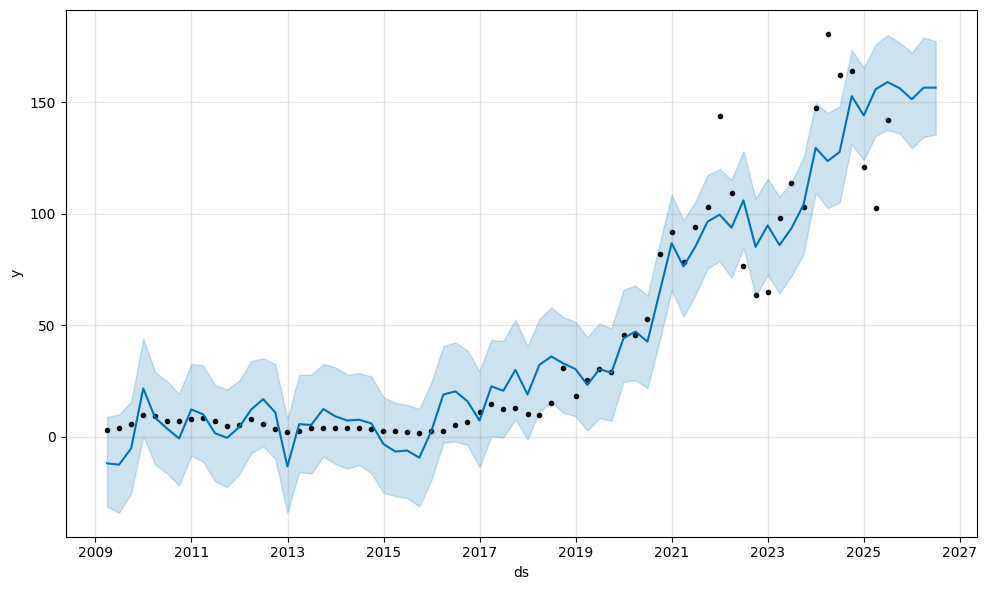

In [15]:
#5) Plot the results

figl = m.plot(forecast)
figl.show()